In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import json
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# --- CẤU HÌNH ---
TICKER = "STB.VN"
DATA_PATH = f'../data/{TICKER}.csv' 
BASE_SAVE_PATH = '../Save_model_ARIMA'

print(f"Đang xử lý cho: {TICKER}")

Đang xử lý cho: STB.VN


Dữ liệu đầu vào:
              Close
Date               
2025-11-19  49500.0
2025-11-20  49500.0
2025-11-21  51300.0
2025-11-24  50000.0
2025-11-25  50000.0


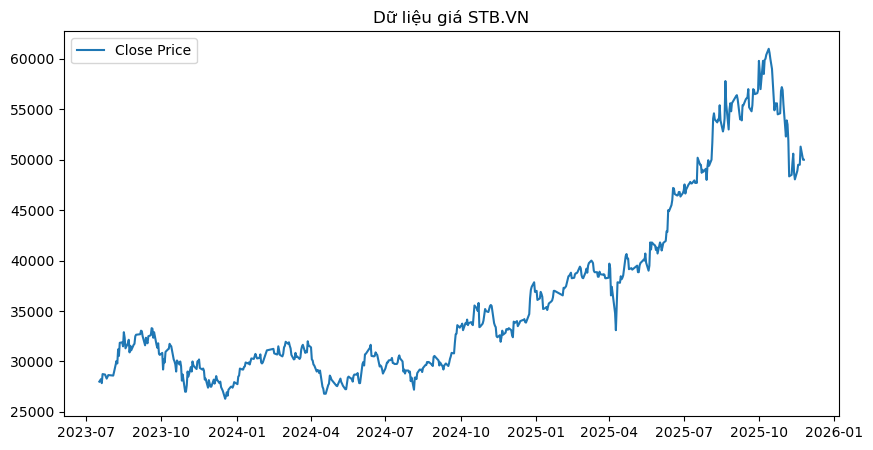

In [2]:
# Đọc file
df = pd.read_csv(DATA_PATH)

# Chuyển đổi ngày tháng
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Lấy cột Close
data = df[['Close']].copy()

# Sắp xếp theo ngày
data = data.sort_index()

# --- QUAN TRỌNG: XỬ LÝ LỊCH ---
# Chứng khoán bị ngắt quãng T7, CN. Ta cần set tần suất (frequency)
# Cách đơn giản nhất: coi như các dòng là liên tiếp (reset index) để train cho mượt,
# sau đó gán lại ngày tháng khi vẽ biểu đồ.
# Tuy nhiên, ở đây ta giữ nguyên Index Date và chỉ dùng dropna() khi cần thiết.

print("Dữ liệu đầu vào:")
print(data.tail())

plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close Price')
plt.title(f'Dữ liệu giá {TICKER}')
plt.legend()
plt.show()

In [3]:
# Chia 80% Train - 20% Test
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print(f"Train samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

Train samples: 464
Test samples: 116


In [4]:
print("Đang tìm model tối ưu... (Việc này có thể mất 1-2 phút)")

# stepwise=True giúp tìm nhanh hơn
# seasonal=False vì dữ liệu giá cổ phiếu hằng ngày thường không có chu kỳ mùa vụ rõ ràng theo năm
model = auto_arima(train_data['Close'], 
                   start_p=1, start_q=1,
                   max_p=5, max_q=5,
                   d=None,          
                   seasonal=False,   
                   trace=True,
                   error_action='ignore',  
                   suppress_warnings=True, 
                   stepwise=True)

print(model.summary())

Đang tìm model tối ưu... (Việc này có thể mất 1-2 phút)
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7266.023, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7264.208, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7264.019, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7264.053, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7263.857, Time=0.01 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.219 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  464
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3630.928
Date:                Sat, 06 Dec 2025   AIC                           7263.857
Time:                        16:24:23   BIC                           7267.994
Sample:                             0   HQIC                          7265.486
                    

5 dòng đầu của dữ liệu dự báo:
            Predicted
Date                 
2025-06-13    45000.0
2025-06-16    45000.0
2025-06-17    45000.0
2025-06-18    45000.0
2025-06-19    45000.0


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


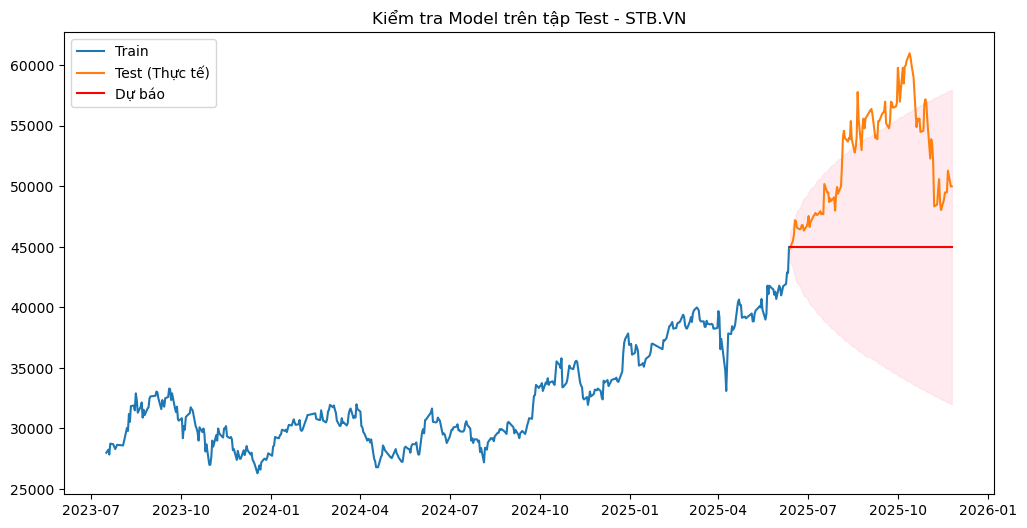

In [5]:

# Dự báo
prediction, conf_int = model.predict(n_periods=len(test_data), return_conf_int=True)


if hasattr(prediction, 'values'):
    prediction_values = prediction.values
else:
    prediction_values = prediction

# Tạo DataFrame chứa kết quả dự báo
prediction_df = pd.DataFrame(prediction_values, index=test_data.index, columns=['Predicted'])

print("5 dòng đầu của dữ liệu dự báo:")
print(prediction_df.head())

# Vẽ biểu đồ kiểm tra nhanh
plt.figure(figsize=(12,6))
plt.plot(train_data['Close'], label='Train')
plt.plot(test_data['Close'], label='Test (Thực tế)')
plt.plot(prediction_df['Predicted'], label='Dự báo', color='red')
plt.fill_between(test_data.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.title(f'Kiểm tra Model trên tập Test - {TICKER}')
plt.legend()
plt.show()

In [6]:

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Gộp thực tế và dự báo vào chung 1 bảng
eval_df = pd.DataFrame({
    'Actual': test_data['Close'],
    'Predicted': prediction_df['Predicted'] # Bây giờ tên cột đã khớp
})

# Lọc bỏ giá trị lỗi (NaN) nếu có
eval_df = eval_df.dropna()

print(f"Số lượng mẫu dùng để đánh giá: {len(eval_df)}")

if len(eval_df) > 0:
    mse = mean_squared_error(eval_df['Actual'], eval_df['Predicted'])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(eval_df['Actual'], eval_df['Predicted'])
    mape = mean_absolute_percentage_error(eval_df['Actual'], eval_df['Predicted']) * 100

    metrics = {
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "MAPE": round(mape, 2)
    }
    
    print("Kết quả đánh giá độ chính xác:")
    print(metrics)
else:
    print("Lỗi: Không có dữ liệu để đánh giá.")

Số lượng mẫu dùng để đánh giá: 116
Kết quả đánh giá độ chính xác:
{'RMSE': 8722.01, 'MAE': 7590.52, 'MAPE': 13.86}


In [7]:
# Retrain trên toàn bộ dữ liệu để có model cập nhật nhất
print("Retrain trên toàn bộ dữ liệu...")
model_full = auto_arima(data['Close'], seasonal=False, stepwise=True, suppress_warnings=True)

# Dự báo 30 ngày
n_days = 30
future_forecast, future_conf = model_full.predict(n_periods=n_days, return_conf_int=True)

# Tạo ngày tương lai
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_days)

# DataFrame tương lai
future_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_forecast,
    'Lower': future_conf[:, 0],
    'Upper': future_conf[:, 1]
})
future_df.set_index('Date', inplace=True)

print("Dự báo 5 ngày tới:")
print(future_df.head())

Retrain trên toàn bộ dữ liệu...
Dự báo 5 ngày tới:
            Forecast         Lower         Upper
Date                                            
2025-11-26   50000.0  48487.916487  51512.083513
2025-11-27   50000.0  47861.590988  52138.409012
2025-11-28   50000.0  47380.994530  52619.005470
2025-11-29   50000.0  46975.832974  53024.167026
2025-11-30   50000.0  46618.878477  53381.121523


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [8]:
# 1. Tạo thư mục
save_dir = os.path.join(BASE_SAVE_PATH, TICKER)
os.makedirs(save_dir, exist_ok=True)

# 2. Lưu Model
joblib.dump(model_full, os.path.join(save_dir, f'{TICKER}_arima_model.pkl'))

# 3. Lưu Metrics
with open(os.path.join(save_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics, f)

# 4. Lưu Dashboard Data (Gộp Lịch sử + Tương lai)
# Gán nhãn để Dashboard phân biệt màu sắc
history_df = data.copy()
history_df.columns = ['Close']
history_df['Type'] = 'History' 

future_save = future_df[['Forecast']].copy()
future_save.columns = ['Close'] # Đặt cùng tên cột Close để vẽ chung 1 trục
future_save['Type'] = 'Forecast'

# Nối lại
final_df = pd.concat([history_df, future_save])
final_df.to_csv(os.path.join(save_dir, 'dashboard_data.csv'))

print(f"Xong! Dữ liệu đã lưu tại: {save_dir}")

Xong! Dữ liệu đã lưu tại: ../Save_model_ARIMA\STB.VN
